# 4) Joint inversion of field data using cross gradients

In this example, we jointly invert ERT and SRT data using cross gradients.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
import pygimli.physics.traveltime as tt


data_ERT = pg.load("../data/AV_DD_2.dat")
data_SRT = pg.load("../data/SRT_P2_coords.sgt")


In [55]:
sensERT = np.array(data_ERT.sensorPositions())
sensSRT = np.array(data_SRT.sensorPositions())
sensERT[:,1] = sensERT[:,2]
sensERT[:,2] = 0.0
sensBoth = np.vstack([sensERT, sensSRT])
ind = np.argsort(sensBoth[:, 0])

In [56]:
sensBoth_sorted = sensBoth[ind]
ind = np.unique(sensBoth_sorted[:, 0], return_index=True)

In [ ]:
sensBoth = sensBoth_sorted[ind[1]]

array([[  0.    , 299.29  ,   0.    ],
       [  0.75  , 299.2225,   0.    ],
       [  1.    , 299.2   ,   0.    ],
       [  1.5   , 299.15  ,   0.    ],
       [  2.    , 299.1   ,   0.    ],
       [  2.25  , 299.07  ,   0.    ],
       [  3.    , 298.98  ,   0.    ],
       [  3.75  , 298.8825,   0.    ],
       [  4.    , 298.85  ,   0.    ],
       [  4.5   , 298.785 ,   0.    ],
       [  5.    , 298.72  ,   0.    ],
       [  5.25  , 298.685 ,   0.    ],
       [  6.    , 298.58  ,   0.    ],
       [  6.75  , 298.52  ,   0.    ],
       [  7.    , 298.5   ,   0.    ],
       [  7.5   , 298.46  ,   0.    ],
       [  8.    , 298.42  ,   0.    ],
       [  8.25  , 298.395 ,   0.    ],
       [  9.    , 298.32  ,   0.    ],
       [  9.75  , 298.2375,   0.    ],
       [ 10.    , 298.21  ,   0.    ],
       [ 10.5   , 298.21  ,   0.    ],
       [ 11.    , 298.21  ,   0.    ],
       [ 11.25  , 298.21  ,   0.    ],
       [ 12.    , 298.21  ,   0.    ],
       [ 12.75  , 298.21 

In [58]:
data_ERT["k"] = ert.createGeometricFactors(data_ERT, numerical=True)
data_ERT["rhoa"] = data_ERT["k"] * data_ERT["r"]

data_ERT["err"] = ert.estimateError(data_ERT, relativeError=0.0175, absoluteError=0.004)

mgr_ERT = ert.ERTManager(data_ERT)
plc = mt.createParaMeshPLC(sensBoth,  paraDepth=15, paraMaxCellSize=0.75)

mesh = mt.createMesh(plc)
mgr_ERT.setMesh(mesh)
print(mesh)

18/09/26 - 13:42:18 - pyGIMLi - INFO - Create default mesh for geometric factor calculation.
18/09/26 - 13:42:25 - pyGIMLi - INFO - Save RVector binary
18/09/26 - 13:42:25 - pyGIMLi - INFO - Cache stored: C:\Users\alexa\AppData\Roaming\pygimli\Cache\6521619961678350688
18/09/26 - 13:42:26 - pyGIMLi - INFO - Found 2 regions.
18/09/26 - 13:42:26 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.


Mesh: Nodes: 2630 Cells: 4939 Boundaries: 7568


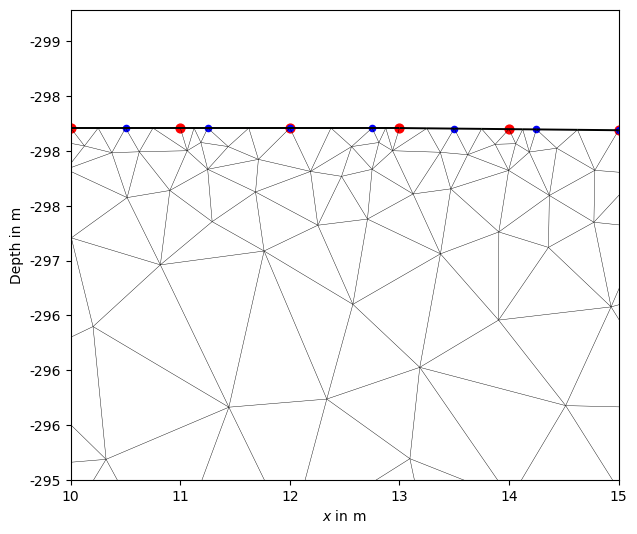

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
pg.show(mesh, ax=ax)
ax.set_ylim(295,)
ax.set_xlim(10, 15)
ax.scatter(data_ERT.sensorPositions()[:, 0], data_ERT.sensorPositions()[:, 2], c="r", s=40, label="Electrodes")
ax.scatter(data_SRT.sensorPositions()[:, 0], data_SRT.sensorPositions()[:, 1], c="b", s=20, label="Geophones")

In [61]:
invArgs = dict(lam = 45, robustData=False, blockyModel=False, verbose=True)

inv = mgr_ERT.invert(**invArgs)

18/09/26 - 13:42:39 - pyGIMLi - INFO - Creating forward mesh from region infos.


18/09/26 - 13:42:39 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
18/09/26 - 13:42:39 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 10198 Cells: 19756 Boundaries: 15136
18/09/26 - 13:42:39 - pyGIMLi - INFO - Use median(data values)=145.18666371511554
18/09/26 - 13:42:39 - pyGIMLi - INFO - Created startmodel from forward operator:4039, min/max=145.186664/145.186664
18/09/26 - 13:42:39 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x00000211BC797100>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 20.48/759
min/max (error): 1.75%/1.77%
min/max (start model): 145/145
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  445.38
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   85.70 (dPhi = 80.40%) lam: 45.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    7.68 (dPhi = 88.99%) lam: 45.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    2.28 (dPhi = 57.98%) lam: 45.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    1.54 (dPhi = 18.60%) lam: 45.0
-------------------------------------------------

(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x211dcea9150>)

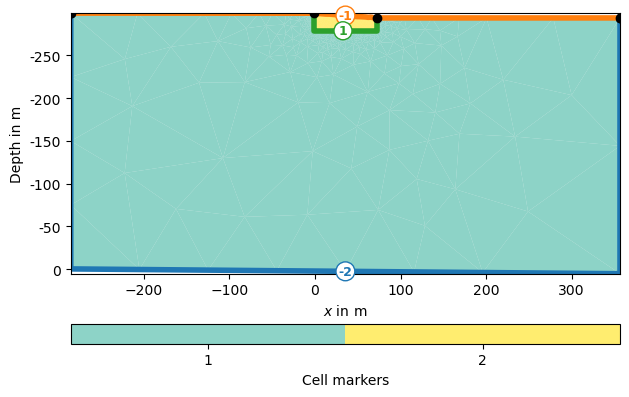

In [62]:
pg.show(mgr_ERT.mesh, markers=True)

In [63]:
meshSRT = mgr_ERT.paraDomain
for c in meshSRT.cells():
    c.setMarker(2)
mgr_SRT = tt.TravelTimeManager(data_SRT)
inv_SRT = mgr_SRT.invert(mesh=meshSRT,maxIter=20, verbose=True)

18/09/26 - 13:46:18 - pyGIMLi - INFO - Found 1 regions.
18/09/26 - 13:46:18 - pyGIMLi - INFO - Creating forward mesh from region infos.
18/09/26 - 13:46:18 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.
18/09/26 - 13:46:18 - pyGIMLi - INFO - Create gradient starting model. 500: 5000
18/09/26 - 13:46:18 - pyGIMLi - INFO - Created startmodel from forward operator:4039, min/max=0.000200/0.002000
18/09/26 - 13:46:18 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.traveltime.modelling.TravelTimeDijkstraModelling object at 0x00000211C703EDE0>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): 0.0013/0.06
min/max (error): 3%/76.86%
min/max (start model): 2.0e-04/0.002
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  363.55
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  226.47 (dPhi = 37.62%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   29.61 (dPhi = 86.51%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    1.15 (dPhi = 91.66%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    1.00 (dPhi = 10.98%) lam: 20.0
----------------------------------------------------------------

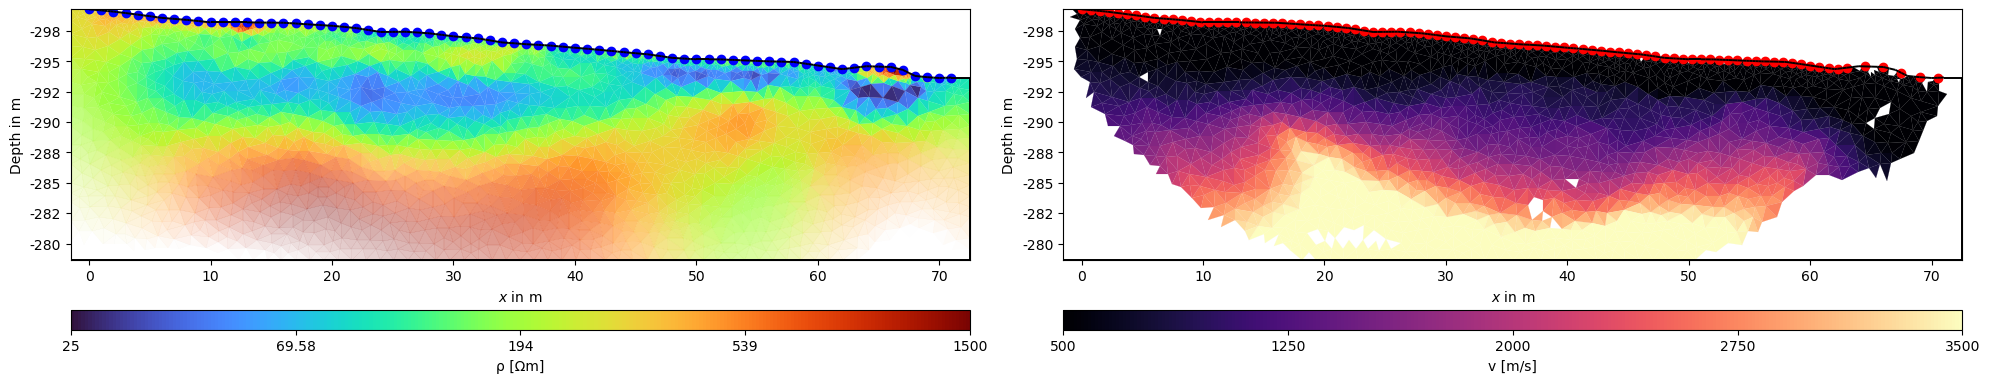

In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
pg.show(mgr_ERT.paraDomain, data=inv, ax=ax1, label='ρ [Ωm]', cMap='turbo', cMin=25, cMax=1500,showMesh=False, logScale=True, coverage=mgr_ERT.coverage())
pg.show(mgr_SRT.paraDomain, data=inv_SRT, ax=ax2, label='v [m/s]', cMap='magma', cMin=500, cMax=3500, showMesh=False, coverage=mgr_SRT.standardizedCoverage())
ax1.scatter(data_ERT.sensors()[:,0], data_ERT.sensors()[:,2], color='blue')
ax2.scatter(data_SRT.sensors()[:,0], data_SRT.sensors()[:,1], color='red')

In [66]:
import jointtools.JItools as JI

crossfop = JI.crossGradient(
    fopList=[mgr_ERT.fop, mgr_SRT.fop], 
    dataList=[data_ERT['rhoa'], data_SRT['t']], 
    errorList=[data_ERT['err'], data_SRT['err']/data_SRT['t']], 
    meshList=[mesh, meshSRT],
    alpha = 0.5,
    smooth = False
    )

18/09/26 - 13:47:29 - pyGIMLi - INFO - Found 2 regions.
18/09/26 - 13:47:29 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.


18/09/26 - 13:47:29 - pyGIMLi - INFO - Creating forward mesh from region infos.
18/09/26 - 13:47:29 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
18/09/26 - 13:47:30 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 10198 Cells: 19756 Boundaries: 15136
18/09/26 - 13:47:30 - pyGIMLi - INFO - Found 1 regions.
18/09/26 - 13:47:30 - pyGIMLi - INFO - Creating forward mesh from region infos.
18/09/26 - 13:47:30 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


In [67]:
dataVec = np.concatenate((np.array(data_ERT['rhoa']), np.array(data_SRT['t'])))
errorVec = np.concatenate((np.array(data_ERT['err']), np.array(data_SRT['err']/data_SRT['t'])))

In [68]:
startmodel_ERT = mgr_ERT.fop.createStartModel(data_ERT['rhoa'])
startmodel_SRT = mgr_SRT.fop.createStartModel(data_SRT['t'])

startmodel = np.concatenate([startmodel_ERT,startmodel_SRT])

#crossfop.createJacobian(startmodel)
#pg.show(crossfop.constraints())

18/09/26 - 13:47:32 - pyGIMLi - INFO - Use median(data values)=145.18666371511554
18/09/26 - 13:47:32 - pyGIMLi - INFO - Create gradient starting model. 500: 5000


In [ ]:
from pygimli.frameworks.inversion import GaussNewtonInversion as GN
inv = GN(fop=crossfop)
modelGN = inv.run(dataVals=dataVec, errorVals=errorVec, startModel=startmodel, verbose=True)
print(r'Final $\chi^2$ = ', inv.chi2())

18/09/26 - 13:48:11 - pyGIMLi - INFO - Starting inversion.


fop: <jointtools.JItools.crossGradient object at 0x00000210BAE14040>
Data transformation: Identity transform
Model transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
min/max (data): 0.0013/759
min/max (error): 1.75%/76.86%
min/max (start model): 2.0e-04/145
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  559.57
--------------------------------------------------------------------------------
inv.iter 1 ... dM:  8078 [-0.361146164157705,...,0.05579642143577151]


18/09/26 - 13:47:33 - pyGIMLi - ERROR - None._drawField(c:\Users\alexa\anaconda3\envs\pg\Lib\site-packages\pygimli\viewer\showmesh.py:399)
Data size invalid
18/09/26 - 13:47:33 - pyGIMLi - ERROR - None.showMesh(c:\Users\alexa\anaconda3\envs\pg\Lib\site-packages\pygimli\viewer\showmesh.py:528)
Coverage needs to be either of type float or an array with the same length as data and mesh.cellCount().


Data:  3651 7.414916932511423 1599.2520827181593 False
Mesh:  Mesh: Nodes: 2209 Cells: 4039 Boundaries: 377
cannot access local variable 'gci' where it is not associated with a value
Traceback (most recent call last):
  File "c:\Users\alexa\anaconda3\envs\pg\Lib\site-packages\pygimli\viewer\showmesh.py", line 426, in showMesh
    gci, validData = _drawField(ax, mesh, data, kwargs)
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\alexa\anaconda3\envs\pg\Lib\site-packages\pygimli\viewer\showmesh.py", line 406, in _drawField
    return gci, validData
           ^^^
UnboundLocalError: cannot access local variable 'gci' where it is not associated with a value


RuntimeError: ./core/src/sparsematrix.h:420		GIMLI::Vector<ValueType2> GIMLI::SparseMapMatrix<ValueType, IndexType>::mult(const GIMLI::Vector<ValueType2>&) const [with ValueType = double; IndexType = long long unsigned int]  0 != 4039

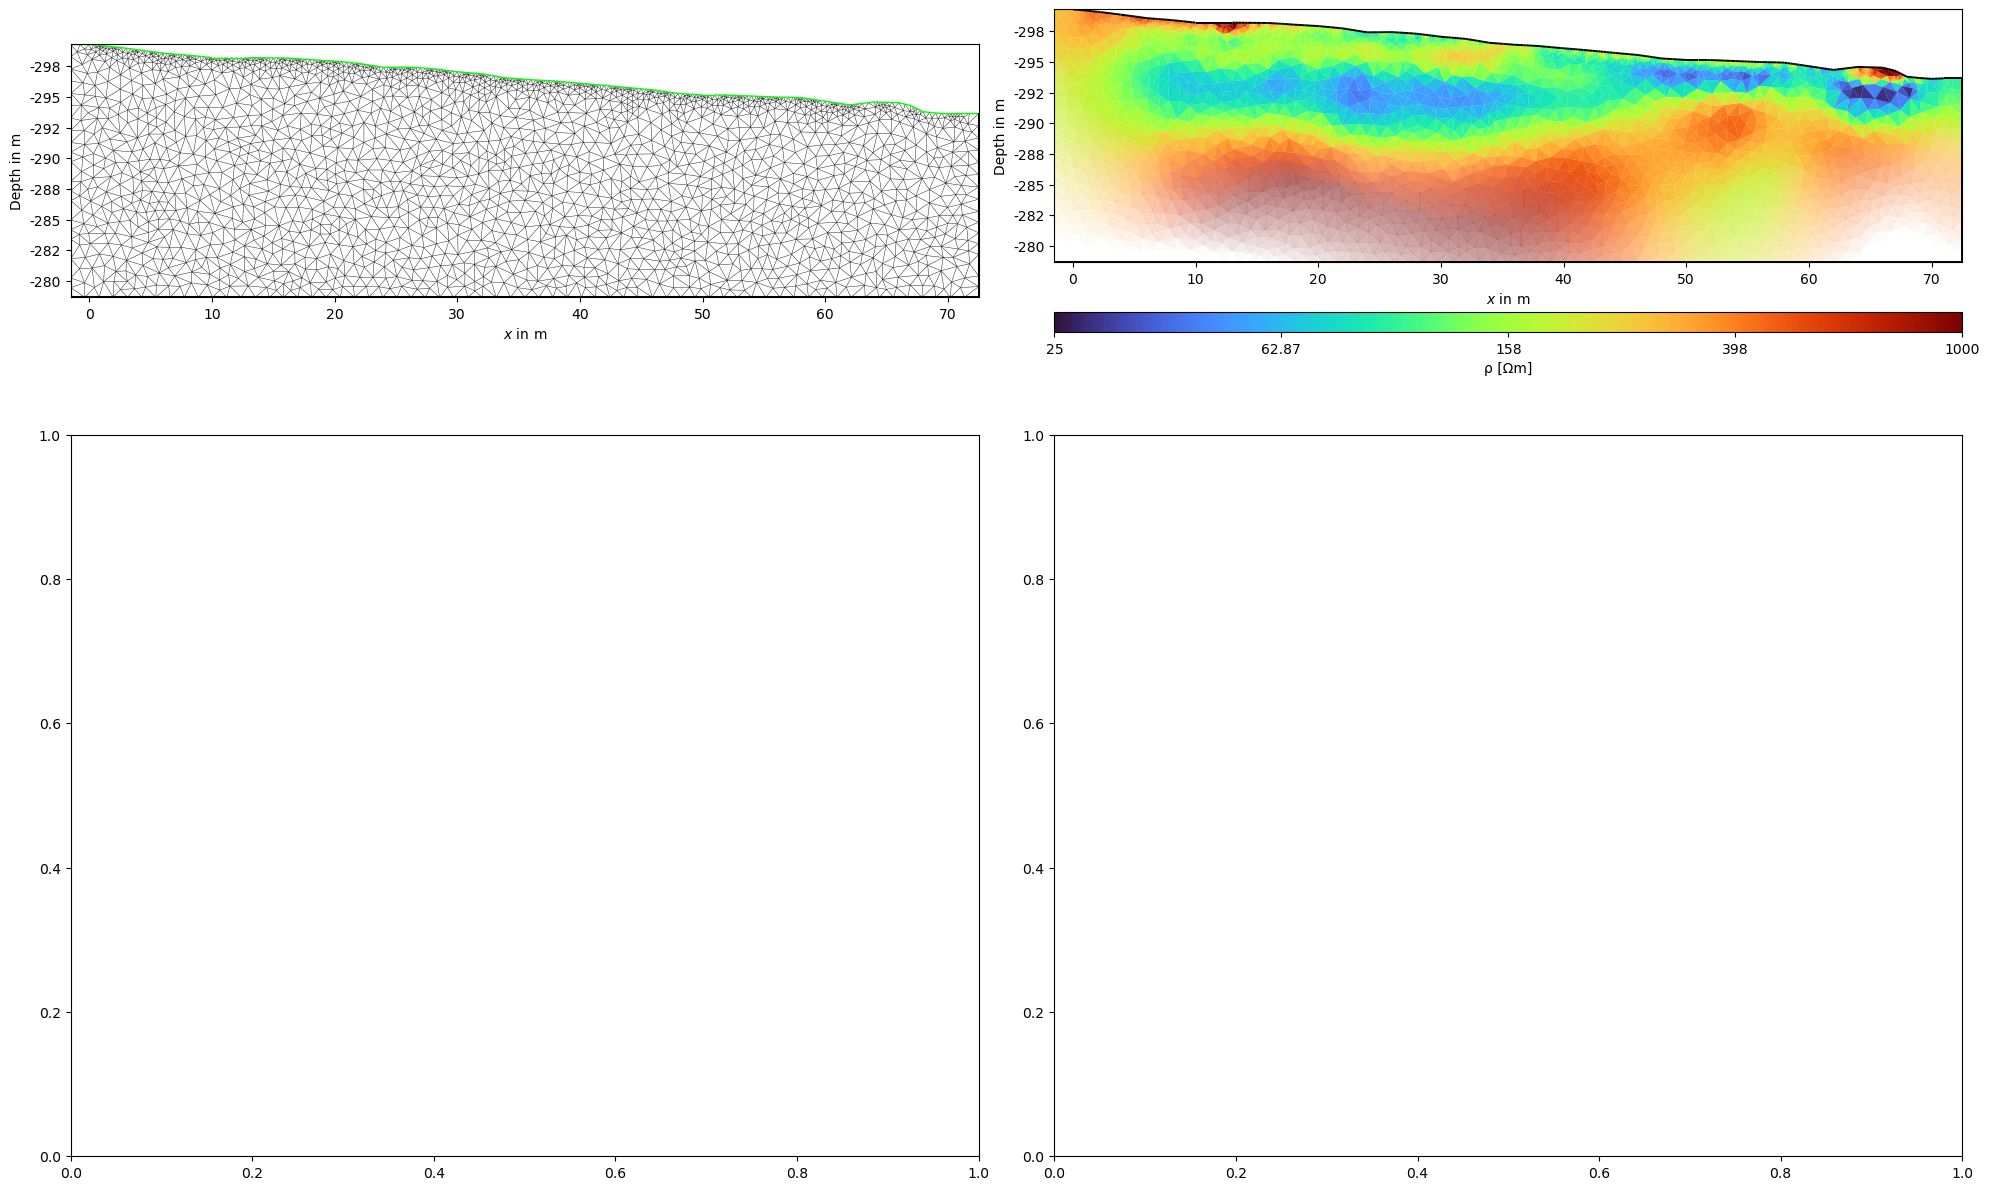

In [70]:
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2, 2, figsize=(20, 14))
pg.show(meshSRT, data=np.split(modelGN,2)[0], ax=ax1, cMap='turbo', cMin=25, cMax=1000, label='ρ [Ωm]', colorBar=True,  logScale=True, coverage=mgr_ERT.coverage())
pg.show(meshSRT, data=mgr_ERT.model, ax=ax2, cMap='turbo', cMin=25, cMax=1000, label='ρ [Ωm]', colorBar=True,  logScale=True, coverage=mgr_ERT.coverage())

pg.show(meshSRT, data=np.split(1/modelGN,2)[1], ax=ax3, cMap='magma', cMin=500, cMax=2500, label='v [m/s]', colorBar=True,  logScale=False, coverage=mgr_SRT.standardizedCoverage())
pg.show(meshSRT, data=mgr_SRT.model, ax=ax4, cMap='magma', cMin=500, cMax=2500, label='v [m/s]', colorBar=True,  logScale=False, coverage = mgr_SRT.standardizedCoverage())

RuntimeError: ./core/src/vector.h:688		GIMLI::Vector<ValueType>& GIMLI::Vector<ValueType>::operator-=(const GIMLI::Vector<ValueType>&) [with ValueType = double]  4039 != 3651

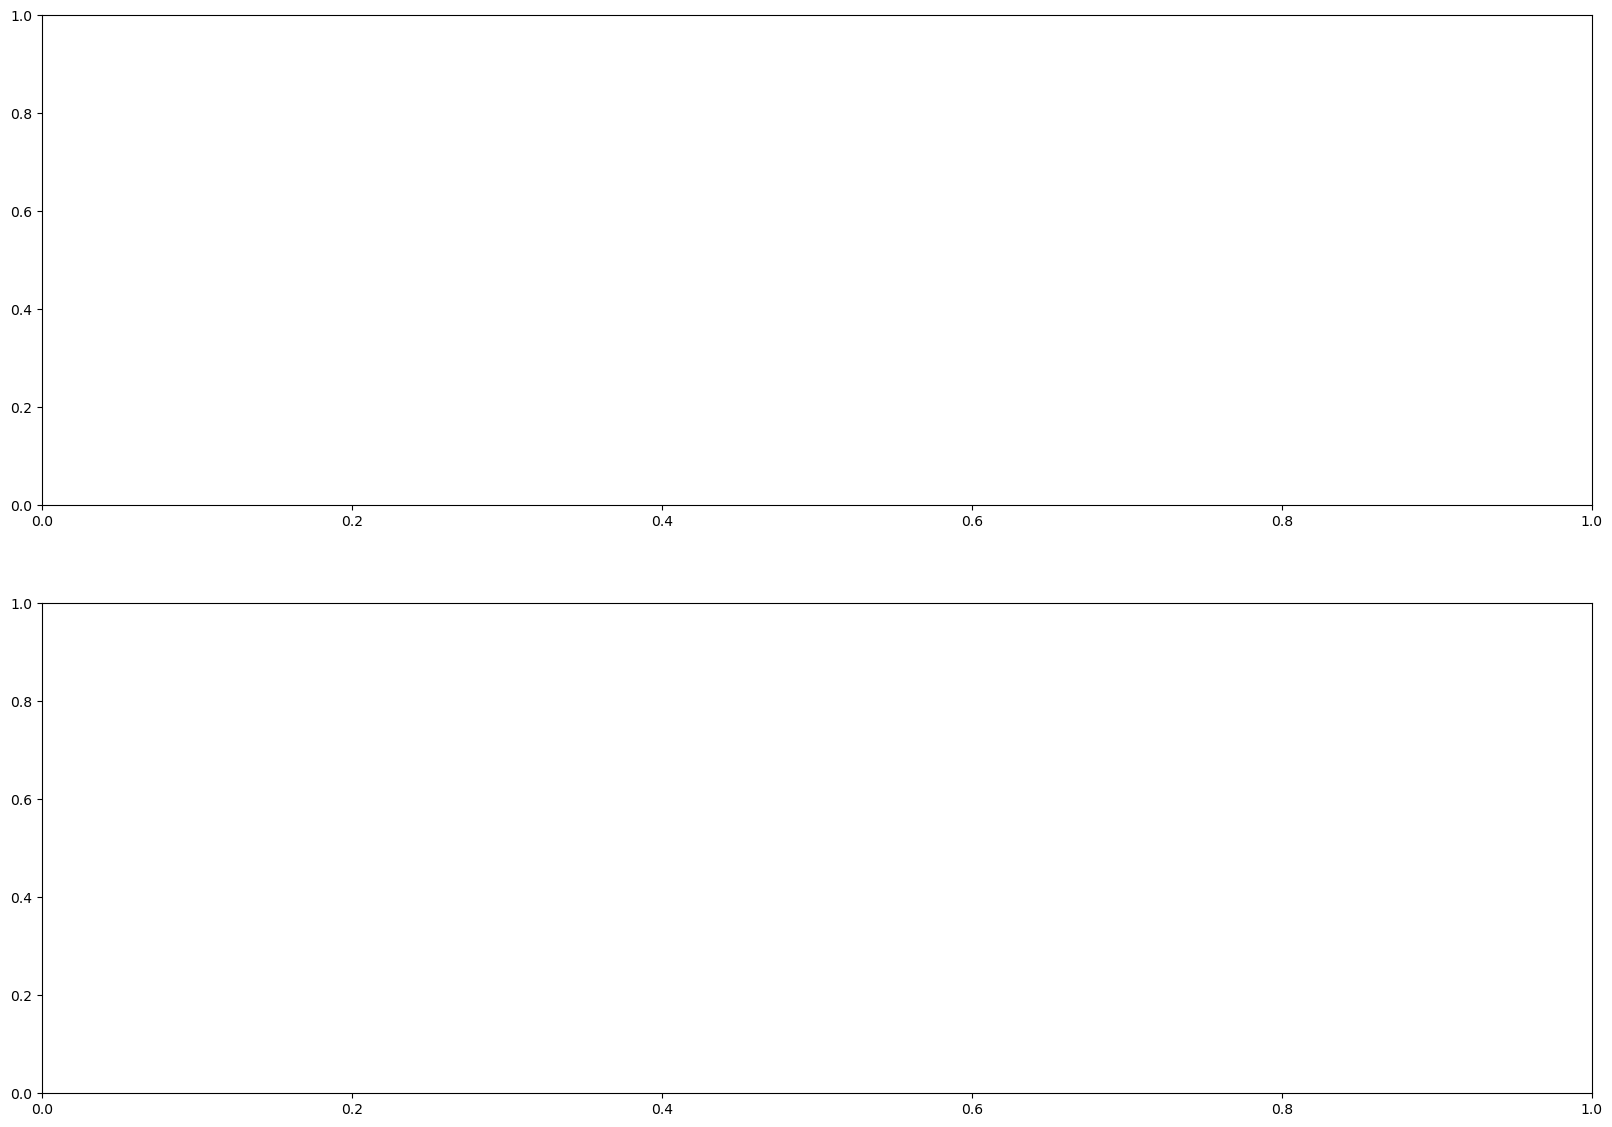

In [71]:
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(20, 14))

pg.show(meshSRT, data=(mgr_ERT.model-np.split(modelGN,2)[0]), ax=ax1, cMap='RdBu', label='ρ [Ωm]', colorBar=True, logScale=False, coverage=mgr_ERT.coverage(), cMin=-100, cMax=100)

pg.show(meshSRT, data=(mgr_SRT.model-np.split(1/modelGN,2)[1]), ax=ax2, cMap='RdBu', label='v [m/s]', colorBar=True,  logScale=False, coverage=mgr_SRT.standardizedCoverage())


In [14]:
mgr_ERT.model-np.split(modelGN,2)[0]

3651 [70.00154762446365,...,-111.4649966240039]